<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
کامنت‌کاوی
</font>
</h1>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
مقدمه و صورت مسئله
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    در این تمرین کاربردی قصد داریم به حل یک مسئله‌ی دنیای واقعی بپردازیم که از جمله مسائل حوزه‌ی <i>پردازش زبان طبیعی (Natural Language Processing یا به اختصار NLP)</i> به شمار می‌رود. در متن‌ها اطلاعات و مفاهیم بسیاری نهفته است که کشف و سامان‌دهی آن‌ها می‌تواند منجر به تولید ارزش‌های زیادی در کاربردهای مختلف شود. یکی از رایج‌ترین سناریوها این است که یک شرکت، وبسایت یا اپلیکیشن قصد دارد کامنت‌های کاربران درباره‌ی محصول یا محصولات خود را به شکل‌های مختلف تحلیل کند تا براساس نتایج به‌دست‌آمده استراتژی کاری خود را تعیین کند. از آنجا که در شرکت‌های بزرگ تعداد کامنت‌های دریافتی بسیار زیاد است و عملاً نیروی انسانی قادر به بررسی تمام آن‌ها نیست از یادگیری ماشین جهت تحلیل و تفسیر این داده‌ها استفاده می‌شود. به عنوان مثال یکی از مسائل کاربردی در این حوزه به این شکل تعیین می‌شود که ماشین موظف است یک کامنت را مطالعه کرده و پیش‌بینی کند که بصورت کلی آیا این کامنت حسی مثبت دارد یا خیر. مثلاً در ارتباط با یک محصول، آیا کاربر از خرید و محصول دریافتی خود رضایت داشته است یا خیر.  به این کاربرد <i>تحلیل احساس (Sentiment Analysis)</i> گفته می‌شود. یا یک مسئله‌ی دیگر که با نام <i>عقیده‌کاوی (Opinion Mining)</i> شناخته می‌شود، کشف عقیده‌ی کاربر در ارتباط با جنبه‌های مختلف یک چیز مثلاً یک محصول است. به عنوان مثال عقیده‌ی کاربر درباره‌ی کیفیت ساخت، گارانتی، قیمت و موارد این چنینی چه بوده است. در این تمرین نیز ما قصد داریم مدلی طراحی کنیم که بتواند صرفاً پیش‌بینی کند آیا در یک کامنت، صحبتی درباره‌ی قیمت یک محصول شده است یا خیر. پس اجازه دهید شروع کنیم و کامنت‌ها را بکاویم تا به قیمت برسیم!
</font>
</p>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
وارد کردن کتابخانه‌های مورد نیاز
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    ابتدا کتابخانه‌های مورد نیازتان را وارد کنید.
</font>
</p>

[Download file](https://quera.org/college/assignments/33728/download_problem_initial_project/149602/)

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
معرفی مجموعه‌داده
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
مجموعه‌داده‌ای که در اختیار شما قرار گرفته مربوط به کامنت‌های ثبت‌شده در وب‌سایت دیجی‌کالا است. هرکدام از کامنت‌های موجود در این مجموعه از نظر اینکه آیا صحبتی از قیمت محصول در آن شده یا خیر برچسب‌گذاری شده است.  ۴۰۰۰۰ کامنت برچسب‌گذاری‌شده به عنوان داده‌های آموزشی و ۸۰۰۰ کامنت دیگر نیز به عنوان داده‌های آزمون در دسترس شماست.
</font>
</p>

<center>
<div dir=rtl style="direction: rtl;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    
|ستون|توضیحات|
|:------:|:---:|
|<code>comment</code>|متن کامنت|
|<code>price_value</code>|آیا درباره‌ی قیمت در آن صحبت شده (<code>1</code>) یا خیر (<code>0</code>)||
    
</font>
</div>
</center>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
خواندن مجموعه‌داده
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    در ابتدا نیاز است فایل‌های مجموعه‌داده را بخوانید. نمونه‌های آموزشی در فایل <code>train.csv</code> و نمونه‌های آزمون که باید برچسب آن‌ها را پیش‌بینی کنید در فایل <code>test.csv</code> ذخیره شده‌اند. اگر لازم دانستید می‌توانید به دلخواه خود بخشی از مجموعه‌ی آموزشی را به عنوان مجموعه‌ی اعتبارسنجی نیز جدا کنید.
</font>
</p>

In [2]:
train_data = pd.read_csv('../data/train.csv')
train_data

,comment,price_value
0,قیمت مناسب وکیفیت خوب پیشنهادمیکنم حتما خرید کنید,1
1,به اندازه یک میلیمتر دورتادور گوشی خالی میماند...,0
2,از همه نظر عالی و یک خرید خوب در قیمت حدود۴۰ ...,1
3,فقط یک بار هر یک ربع ساعت 1 درصد شارژ کرد بعدش...,0
4,قیمت این کالا خیلی تغییر میکنه . من خریدم چندر...,1
...,...,...
39995,خیلی خوبه واسه گوشی m20ولی یه ترک از پایین داش...,0
39996,چند روزه دارم استفاده میکنم در یک کلام عالیه\r...,1
39997,من سی تومن خریدم و با توجه به قیمت ارزش خرید د...,1
39998,عالیه از هر نظر \nهم قیمتش کمه \nهم قطعاتش زیا...,0


In [3]:
test_data = pd.read_csv('../data/test.csv')
test_data

,comment
0,با این قیمت بیرون جنس خوبی پیدا نمیشه، واقعا ر...
1,خیلی شیکه جنسش هم خوبه قابل استفاده است توصیه ...
2,خوب نیست بهتر میشه پیدا کرد به نظر من از هر لح...
3,شکل خوبی داره راضیم واسه جهیزیه دخترم خریدم
4,با توجه به اینکه گوشی رو برای مادرم خریدم و تو...
...,...
7995,بهترین کرم مرطوب کننده ای هست که برا دست تا ال...
7996,به نظر تو شگفت انگیز ارزش خرید داره البته خدای...
7997,از شیشه درآوردم و آبش رو هم خالی کردم گذاشتم ر...
7998,اصلا اونی نبود ک سفارش دادم یه مارک دیگه با یه...


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
پیش‌پردازش و مهندسی ویژگی
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
پیش‌پردازش متن و نحوه‌ی بازنمایی آن به شکل عددی یکی از تاثیرگذارترین عوامل در عملکرد مدل است. در پیش‌پردازش باید سعی کنیم متن را به گونه‌ای پاک‌سازی کنیم که ویژگی‌های مفیدتری در آن دیده شود و کلمات نادر و بی‌اهمیت از آن حذف شوند تا کار مدل راحت‌تر شود. علاوه بر این از آنجا که ماشین تنها قادر به محاسبات عددی است و درکی از رشته‌ها ندارد باید بتوانیم از کلمات موجود در متن ویژگی‌های عددی بامعنایی تولید کنیم و آن‌ها را به عنوان ورودی مدل خود در نظر بگیریم.
<br>
 تکنیک‌های پیش‌پردازش و پاک‌سازی متفاوتی برای متن وجود دارد که هم می‌توانید با جست‌وجو در اینترنت با آن‌ها آشنا شوید و هم می‌توانید از ایده‌های خلاقانه خودتان استفاده کنید. اما به چند نمونه از رایج‌ترین آن‌ها اشاره خواهیم کرد:
</font>
</p>
<ul dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<li><b>حذف کلمات توقف (stop words):</b> برخی کلمات هستند که در متن‌ها به تعداد بسیار زیادی تکرار می‌شوند اما بار معنایی خاصی ندارند و معمولاً در مسائل مرتبط با پردازش زبان نه تنها تاثیر مثبتی در عملکرد مدل نمی‌گذارند بلکه پرتکرار بودن آن‌ها ارزش زیادی را به این کلمات می‌دهد. از جمله‌ی این کلمات در فارسی می‌توان به «از»، «به»، «است»، «آنان»، «آخر»، «آنجا» و ... اشاره کرد. شما می‌توانید در متن خود با توجه به مسئله‌ای که تعریف می‌کنید نسبت به حذف این کلمات اقدام کنید. البته توجه داشته باشید که برخی کلمات می‌‍توانند بصورت رایج کلمه‌ی توقف شناخته شوند اما در مسئله‌ی خاص شما اتفاقاً با اهمیت باشند.</li>
<li><b>حذف اعداد و حروف اضافه: </b>اعداد و حروف اضافه نیز همچون کلمات توقف ممکن است با توجه به مسئله بی‌اهمیت باشند و بتوان آن‌ها را به‌کلی حذف کرد. البته ایده‌ی دیگری وجود دارد که به‌جای هر عدد یک توکن خاص مثلاً <code>NUMBER</code> قرار دهید.</li>
<li><b>نرمال‌سازی (normalization):</b> انجام برخی اصلاحات رایج در متن جهت نرمال کردن کلمات نیز تکنیک دیگری است که کاربرد زیادی دارد. به عنوان مثال در زبان فارسی رعایت نیم‌فاصله می‌تواند یک نرمال‌سازی بسیار مفید شناخته شود. اگر این کار صورت نگیرد به عنوان مثال کلمه‌ی «نیم فاصله» با کلمه‌ی «نیم‌فاصله» کاملاً متفاوت در نظر گرفته می‌شود. اولی خود شامل دو کلمه‌ی مجزاست در حالیکه دومی یک کلمه‌ی واحد است.</li>
<li><b>ریشه‌یابی (stemming)</b> تکنیک دیگر تبدیل کلمات به ریشه‌ی آن‌هاست. به عنوان مثال در زبان فارسی «کتاب‌ها» را می‌توان با ریشه‌ی خود یعنی «کتاب» جایگزین کنیم. با این جایگزینی مفهوم کلمه عوض نخواهد شد اما کار ماشین با متن بسیار راحت می‌شود زیرا در این حالت بین این دو تمایزی قائل نمی‌شود.</li>
</ul>
<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
در این قسمت از شما خواسته شده تا تابعی به نام <code>preprocessing</code> تعریف کنید که یک متن را به عنوان ورودی گرفته و سپس پیش‌پردازش‌های دلخواه شما بر روی آن انجام شود و در نهایت یک لیست از توکن‌های موجود در آن را برگرداند. منظور از توکن، هرکدام از اجزای موجود در متن است که کلمات، حروف،‌اعداد و... را  شامل می‌شود. به عنوان یک مثال اگر تابع شما جمله‌ی زیر را دریافت کند:
</font>
</p>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
<center>
'از همه نظر عالی و یک خرید خوب در  قیمت حدود۴۰ تومن'
</center>
</font>
</p>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
خروجی زیر برای آن تولید می‌شود: (توجه کنید که نیازی نیست خروجی تابع شما دقیقاً مشابه با این مثال باشد و مراحل پیش‌پردازش کاملاً به دلخواه شماست)
</font>
</p>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
<center>
['نظر', 'عالی', 'خرید', 'خوب', 'قیمت', 'تومن']
</center>
</font>
</p>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
<b>نکته:</b> برای پیش‌پردازش متون فارسی کتابخانه‌ها و ابزارهای مختلفی وجود دارد که می‌توانید به دلخواه خود از آن‌ها استفاده کنید. با این حال یکی از رایج‌ترین کتابخانه‌ها <a href="https://www.roshan-ai.ir/hazm/" target=”_blank”>هضم</a> است که می‌توانید با نصب آن در محیط کار خود از ابزارهای موجود در آن بهره ببرید.
برای دسترسی به لیست کلمات توقف فارسی می‌توانید به کمک <code>from hazm import stopwords_list</code>، لیست هضم را دریافت کنید.
</font>
</p>

In [ ]:
from hazm import Normalizer, word_tokenize, Lemmatizer
from hazm import stopwords_list
import re

In [ ]:
sample_text = 'از همه نظر عالی و یک خرید خوب در  قیمت حدود۴۰ تومن'

print(f"Original text: {sample_text}")
print(f"Length: {len(sample_text)} characters")

Original text: از همه نظر عالی و یک خرید خوب در  قیمت حدود۴۰ تومن
Length: 50 characters


In [8]:
def clean_text(text):
    """
    Clean the input text by removing unwanted characters and patterns
    """
    # Remove HTML tags if any
    text = re.sub(r'<[^>]+>', '', text)
    
    # Remove newlines and carriage returns
    text = text.replace('\n', ' ').replace('\r', ' ')
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Test on sample
cleaned = clean_text(sample_text)
print(f"Cleaned text: {cleaned}")

Cleaned text: از همه نظر عالی و یک خرید خوب در قیمت حدود۴۰ تومن


In [9]:
# Initialize the normalizer
normalizer = Normalizer()

def normalize_text(text):
    """
    Normalize Persian text using Hazm's Normalizer
    This handles character variations, half-spaces, etc.
    """
    normalized = normalizer.normalize(text)
    return normalized

# Test on cleaned sample
normalized = normalize_text(cleaned)
print(f"Normalized text: {normalized}")

Normalized text: از همه نظر عالی و یک خرید خوب در قیمت حدود ۴۰ تومن


In [10]:
def tokenize_text(text):
    """
    Split text into individual tokens using Hazm's word_tokenize
    """
    tokens = word_tokenize(text)
    return tokens

# Test on normalized sample
tokens = tokenize_text(normalized)
print(f"Tokens: {tokens}")
print(f"Number of tokens: {len(tokens)}")

Tokens: ['از', 'همه', 'نظر', 'عالی', 'و', 'یک', 'خرید', 'خوب', 'در', 'قیمت', 'حدود', '۴۰', 'تومن']
Number of tokens: 13


In [11]:
stop_words = set(stopwords_list())

print(f"sample of stop words : {list(stop_words)[:20]} ")

def remove_stopwords(tokens):
    """
    Remove Persian stop words from the token list
    """
    filtered_tokens = [token for token in tokens if token not in stop_words]
    return filtered_tokens

filtered = remove_stopwords(tokens)
print(f"Tokens without stop words: {filtered}")

sample of stop words : ['چیز', 'کردم', 'سی', 'بندی', 'دارد', 'می\u200cکنیم', 'سپس', 'می\u200cشود', 'لحاظ', 'شوند', 'مورد', 'شاید', 'آنجا', 'اگر', 'همواره', 'سبب', 'جمع', 'کمی', 'برابر', 'روبه'] 
Tokens without stop words: ['خرید', 'قیمت', '۴۰', 'تومن']


In [12]:
lemmatizer = Lemmatizer()

def lemmatize_tokens(tokens):
    """
    Convert each token to its root form
    """

    lemmatized = [lemmatizer.lemmatize(token) for token in tokens]
    return lemmatized

lemmatized = lemmatize_tokens(filtered)
print(f"Lemmatized tokens: {lemmatized}")

Lemmatized tokens: ['خرید', 'قیمت', '۴۰', 'تومن']


In [13]:
def preprocessing(text):
    """
    Complete preprocessing pipeline for Persian text
    Input: raw text string
    Output: list of processed tokens
    """
    # Step 1: Clean text (remove HTML, newlines, extra spaces)
    text = re.sub(r'<[^>]+>', '', text)
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 2: Normalize Persian characters
    text = normalizer.normalize(text)
    
    # Step 3: Tokenize
    tokens = word_tokenize(text)
    
    # Step 4: Remove stop words
    tokens = [token for token in tokens if token not in stop_words]
    
    # Step 5: Lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return tokens

# Test the complete function
result = preprocessing(sample_text)
print(f"Final processed tokens: {result}")

Final processed tokens: ['خرید', 'قیمت', '۴۰', 'تومن']


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
مدل‌سازی
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
در این قسمت گام به گام به انجام محاسبات لازم جهت اجرای الگوریتم بیز ساده‌لوحانه (Naive Bayes) خواهیم پرداخت. در ابتدا نیاز است تا احتمال هر کلاس (<code>price_value</code> برابر <code>0</code> یا <code>1</code>) را محاسبه کنید. برای این کار تعداد داده‌های متعلق به آن کلاس را بر تعداد کل داده‌ها تقسیم کنید. حاصل را بصورت دیکشنری با فرمت <code dir=ltr>{0: P0, 1: P1}</code> در متغیر <code>prior_probability</code> ذخیره کنید. به جای <code>P0</code> احتمال برچسب <code>0</code> و به جای <code>P1</code> احتمال برچسب <code>1</code> را قرار دهید. <code>
</font>
</p>


In [14]:
def calculate_prior_probabilities(y_train):
    """
    Calculate the prior probability of each class
    P(class) = number of samples in class / total number of samples
    
    Args:
        y_train: Series containing the labels (0 or 1)
    
    Returns:
        Dictionary with format {0: P0, 1: P1}
    """
    # Count total number of samples
    total_samples = len(y_train)
    
    # Count samples for each class
    class_counts = y_train.value_counts()
    
    # Calculate probability for each class
    prior_probability = {
        0: class_counts.get(0, 0) / total_samples,
        1: class_counts.get(1, 0) / total_samples
    }
    
    return prior_probability

# Extract labels from training data
y_train = train_data['price_value']

# Calculate prior probabilities
prior_probability = calculate_prior_probabilities(y_train)

# Display results
print("Prior Probabilities:")
print(f"P(price_value = 0): {prior_probability[0]:.4f}")
print(f"P(price_value = 1): {prior_probability[1]:.4f}")
print(f"\nprior_probability dictionary: {prior_probability}")

Prior Probabilities:
P(price_value = 0): 0.5200
P(price_value = 1): 0.4800

prior_probability dictionary: {0: 0.520025, 1: 0.479975}


Class Distribution:
price_value
0    20801
1    19199
Name: count, dtype: int64

Total samples: 40000


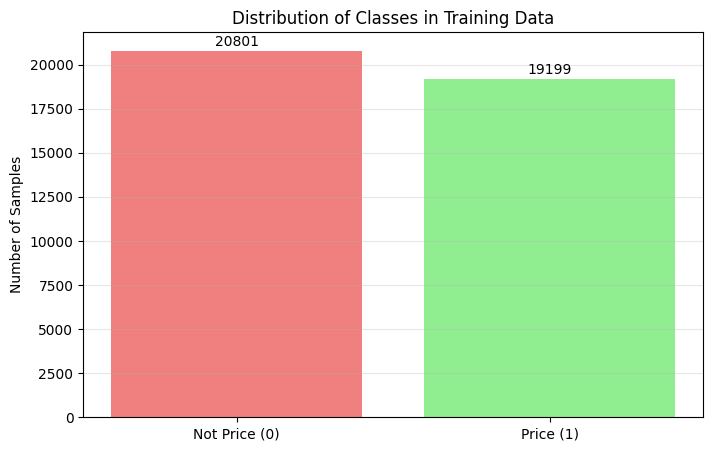


Percentage of non-price comments: 52.00%
Percentage of price comments: 48.00%


In [15]:
# Let's verify our calculations by looking at the actual distribution
import matplotlib.pyplot as plt

# Count values
class_distribution = y_train.value_counts()
print("Class Distribution:")
print(class_distribution)
print(f"\nTotal samples: {len(y_train)}")

# Visualize
plt.figure(figsize=(8, 5))
plt.bar(['Not Price (0)', 'Price (1)'], 
        [class_distribution[0], class_distribution[1]], 
        color=['lightcoral', 'lightgreen'])
plt.title('Distribution of Classes in Training Data')
plt.ylabel('Number of Samples')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate([class_distribution[0], class_distribution[1]]):
    plt.text(i, v + 100, str(v), ha='center', va='bottom')

plt.show()

# Print percentages
print(f"\nPercentage of non-price comments: {(class_distribution[0]/len(y_train))*100:.2f}%")
print(f"Percentage of price comments: {(class_distribution[1]/len(y_train))*100:.2f}%")

In [16]:
# The prior_probability is already in the required format {0: P0, 1: P1}
print("Final prior_probability:")
print(prior_probability)

# Let's verify the format and values
assert isinstance(prior_probability, dict), "prior_probability should be a dictionary"
assert 0 in prior_probability and 1 in prior_probability, "Dictionary should have keys 0 and 1"
assert abs(sum(prior_probability.values()) - 1.0) < 1e-10, "Probabilities should sum to 1"

print("\n✓ Format check passed!")
print(f"✓ Sum of probabilities: {sum(prior_probability.values()):.4f}")

Final prior_probability:
{0: 0.520025, 1: 0.479975}

✓ Format check passed!
✓ Sum of probabilities: 1.0000


<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
حال باید احتمال وقوع هر توکن در هر کلاس را به دست آوریم. برای این کار ویژگی ورودی مدل را تعداد رخداد یک توکن در نظر می‌گیریم. پس در ابتدا تابع <code>token_counter</code> را به گونه‌ای تکمیل کنید که مجموعه‌ای (آرایه‌ای) از متن‌ها را به عنوان ورودی گرفته و یک دیکشنری از تعداد رخداد هر کلمه در میان تمام آن‌ها تولید کند. یعنی به ازای هر متن موجود در ورودی، ابتدا آن را به تابع <code>preprocessing</code> بدهید تا پیش‌پردازش‌های مختلف را روی متن اعمال کند و توکن‌های موجود در آن را برگرداند. سپس به ازای هر توکن یک واحد به تعداد رخداد آن در دیکشنری اضافه کنید. فرمت دیکشنری شما باید به گونه‌ای باشد که نمایه‌ی آن، یک کلمه و مقدار آن، تعداد رخداد آن کلمه در میان تمام متون ورودی تابع باشد.
</font>
</p>


In [17]:
def token_counter(texts):
    """
    Count occurrences of each token across all input texts
    
    Args:
        texts: Array/list of text comments
    
    Returns:
        Dictionary where keys are tokens and values are their frequencies
    """
    count_dict = {}

    for text in texts:
        tokens = preprocessing(text)

        for token in tokens:
            if token in count_dict:
                count_dict[token] += 1
            else:
                count_dict[token] = 1
                
    return count_dict

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
اکنون می‌توانید متون هرکدام از کلاس‌ها را به تابع <code>token_counter</code> بدهید تا تعداد رخداد هر کلمه در آن کلاس شمرده شود. یکبار کامنت‌هایی که برچسب <code>0</code> دارند را جدا کرده و به این تابع بدهید و خروجی را در متغیر <code>negative_class_count</code> ذخیره کنید. بار دیگر همین کار را برای برچسب <code>1</code> تکرار کرده و نتیجه را در متغیر <code>positive_class_count</code> ذخیره کنید.
</font>
</p>
<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
<span style="color: green"><b>نکته: </b></span> در این تمرین اگر برخی سلول‌ها تا یک یا چند دقیقه طول کشیدند تعجب نکنید و به علت حجم بالای داده و محاسبات طبیعی است.
</font>
</p>


In [20]:
texts_class_0 = train_data[train_data['price_value'] == 0]['comment']
texts_class_1 = train_data[train_data['price_value'] == 1]['comment']

In [21]:
print(f"Processing {len(texts_class_0)} texts for class 0...")
print(f"Processing {len(texts_class_1)} texts for class 1...")
print("This may take a minute or two due to the large dataset size...")

Processing 20801 texts for class 0...
Processing 19199 texts for class 1...
This may take a minute or two due to the large dataset size...


In [22]:
# Count tokens for negative class (price_value = 0)
negative_class_count = token_counter(texts_class_0)

# Count tokens for positive class (price_value = 1)
positive_class_count = token_counter(texts_class_1)

print(f"\n✓ Processing complete!")
print(f"Unique tokens in negative class (0): {len(negative_class_count)}")
print(f"Unique tokens in positive class (1): {len(positive_class_count)}")


✓ Processing complete!
Unique tokens in negative class (0): 20495
Unique tokens in positive class (1): 18373


<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
وقت آن رسیده که به طراحی بخش اصلی الگوریتم یعنی محاسبه‌ی احتمال یک کلاس به شرط یک متن بپردازیم تا آن کلاسی که بیشترین احتمال را کسب کرده به عنوان پیش‌بینی خروجی داده شود. جهت محاسبه‌ی احتمال یک کلاس به شرط مشاهده‌ی یک متن (لیستی از توکن‌ها) طبق ایده‌ی الگوریتم بیز ساده‌لوحانه کافیست احتمال رخداد هرکدام از اجزای آن (در اینجا توکن‌ها) را به شرط آن کلاس محاسبه کرده و در همدیگر ضرب کنیم. حاصل را نیز در نهایت در احتمال آن کلاس ضرب خواهیم کرد. یعنی خواهیم داشت:
</font>
</p>

$P(class|t_1, t_2, ..., t_n)=P(t_1, t_2, ..., t_n|class)\times P(class)=P(t_1|class)\times P(t_2|class)\times ...\times P(t_n|class)\times P(class)$

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
و اما برای محاسبه‌ی احتمال رخداد هر توکن به شرط یک کلاس می‌توانیم تعداد رخداد توکن در میان متن‌های آن کلاس را بر مجموع رخداد توکن‌های متون مربوط به آن کلاس تقسیم کنیم. تعداد رخداد هر توکن در هر کلاس در دیکشنری‌های <code>positive_class_count</code> و <code>negative_class_count</code> ذخیره شده است. مجموع رخداد توکن‌های یک کلاس را نیز می‌توانید با جمع تمام مقادیر موجود در دیکشنری آن کلاس به‌دست آورید. اگر بخواهیم مفهوم این قسمت را به شکل فرمول نمایش دهیم خواهیم داشت:
</font>
</p>

$\large P(w_i|class)=\frac{count(t_i, class)}{\sum_{t \in V}{count(t, class)}}$

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
با این حال فرمول بالا چندان عملکرد خوبی نخواهد داشت. فرض کنید یک متن آزمون دارید و می‌خواهید احتمال هر توکن آن در یک کلاس را محاسبه کنید اما آن توکن تاکنون دیده نشده و تعداد رخدادش صفر است. در اینصورت احتمال توکن به شرط کلاس معادل صفر شده و هنگامیکه این عدد در احتمال سایر توکن‌ها ضرب می‌شود حاصل را به کلی صفر می‌کند. جهت رفع این مشکل ایده‌ای با نام <i>add-1 smoothing</i> مطرح می‌شود که می‌گوید تعداد رخداد کلمه‌ای که تاکنون دیده‌نشده به‌جای صفر معادل یک در نظر گرفته شود. جهت اعمال این تغییر لازم است به تعداد تکرار تمام توکن‌ها نیز یک واحد اضافه کنیم و جهت آنکه نسبت‌ها به هم نخورد نیاز است تا در مخرج کسر نیز اندازه‌ی لغت‌نامه را قرار دهیم. منظور از لغت‌نامه که آن را در فرمول با <code>V</code> نشان می‌دهیم تمام توکن‌های یکتای موجود است. یعنی باید توکن‌های موجود در دیکشنری تمام کلاس‌ها را با هم ترکیب کنید و موارد یکتا را به دست آورید. با اعمال تغییراتی که شرح داده شد نهایتاً به فرمول زیر خواهیم رسید:
</font>
</p>

$\large P(w_i|class)=\frac{count(t_i, class) + 1}{(\sum_{t \in V}{count(t, class)}) + |V|}$

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
حال از شما می‌خواهیم که در تابع <code>compute_probability</code> یک متن و یک کلاس (<code>0</code> یا <code>1</code>) را گرفته و طبق فرمول‌های معرفی‌شده به محاسبه‌ی احتمال آن کلاس به شرط آن متن بپردازد. یعنی نیاز است احتمال هر توکن به شرط آن کلاس را محاسبه کرده، حاصل تمام آن‌ها را در هم ضرب کرده، نهایتاً در احتمال آن کلاس ضرب کنید و حاصل را برگردانید.
</font>
</p>

In [23]:
vocabulary = set(negative_class_count.keys()) | set(positive_class_count.keys())
vocab_size = len(vocabulary)

# Calculate total token occurrences for each class
total_negative_tokens = sum(negative_class_count.values())
total_positive_tokens = sum(positive_class_count.values())

print(f"Vocabulary size (|V|): {vocab_size:,}")
print(f"Total tokens in negative class: {total_negative_tokens:,}")
print(f"Total tokens in positive class: {total_positive_tokens:,}")

Vocabulary size (|V|): 28,902
Total tokens in negative class: 286,158
Total tokens in positive class: 276,675


In [24]:
import math

In [25]:
import math

def compute_probability(text, cls):
    """
    Calculate the probability of a class given a text using Naive Bayes with add-1 smoothing
    
    Args:
        text: Input text string
        cls: Class label (0 or 1)
    
    Returns:
        Probability P(class | text)
    """
    # Step 1: Preprocess the text to get tokens
    tokens = preprocessing(text)
    
    # Step 2: Select the appropriate count dictionary and total based on class
    if cls == 0:
        class_count = negative_class_count
        total_class_tokens = total_negative_tokens
    else:  # cls == 1
        class_count = positive_class_count
        total_class_tokens = total_positive_tokens
    
    # Step 3: Calculate probability using log to avoid underflow
    # log(P(class|tokens)) = log(P(class)) + sum(log(P(token|class)))
    
    # Start with log of prior probability
    log_probability = math.log(prior_probability[cls])
    
    # Step 4: For each token, calculate P(token|class) with add-1 smoothing
    for token in tokens:
        # Get count of token in this class (0 if not seen)
        token_count = class_count.get(token, 0)
        
        # Apply add-1 smoothing formula:
        # P(token|class) = (count(token, class) + 1) / (total_tokens + |V|)
        token_probability = (token_count + 1) / (total_class_tokens + vocab_size)
        
        # Add log probability (using log to avoid numerical underflow)
        log_probability += math.log(token_probability)
    
    # Return the actual probability (not log probability)
    return math.exp(log_probability)

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
اکنون تابع <code>predict</code> را به گونه‌ای تکمیل کنید که لیستی از متن‌ها را گرفته و یک آرایه‌ی نامپای تک‌بعدی از برچسب پیش‌بینی‌شده برای آن‌ها تولید کند. جهت پیش‌بینی برچسب یک متن کافیست متن ورودی را یک‌بار با کلاس <code>0</code> و یک‌بار با کلاس <code>1</code> به تابع <code>compute_proability</code> بدهید تا احتمال هر کلاس محاسبه شود. سپس آن کلاسی که مقدار احتمال بیشتری را تولید کرده است به عنوان برچسب پیش‌بینی‌شده انتخاب کنید.
</font>
</p>

In [26]:
import numpy as np

def predict(texts):
    """
    Predict class labels for a list of texts
    
    Args:
        texts: List/array of text strings
    
    Returns:
        NumPy array of predicted labels (0 or 1)
    """
    predictions = []
    
    # Iterate through each text
    for text in texts:
        # Calculate probability for each class
        prob_0 = compute_probability(text, 0)
        prob_1 = compute_probability(text, 1)
        
        # Select the class with higher probability
        if prob_1 > prob_0:
            predictions.append(1)
        else:
            predictions.append(0)
    
    # Convert to numpy array
    return np.array(predictions)

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
ارزیابی
</font>
</h3>
<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
ساخت مدل بیز ساده‌لوحانه به اتمام رسید و اکنون می‌توانید متن‌های خود را به مدل بدهید تا برچسب آن‌ها را پیش‌بینی کند. در این مرحله می‌توانید ابتدا داده‌های آموزشی را به تابع <code>predict</code> بدهید و پیش‌بینی‌های تولیدی را با برچسب‌های واقعی مقایسه کنید تا دقت مدل خود را بر روی داده‌های آموزشی بسنجید. این دقت می‌تواند تا حدی در اطمینان شما به پیاده‌سازیِ انجام‌گرفته کمک کند. جهت محاسبه‌ی دقت می‌توانید از تابع آماده‌ی <code>accuracy_score</code> استفاده کنید و در سیستم داوری نیز خروجی شما با این معیار سنجیده خواهد شد.
</font>
</p>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font color="red"><b color='red'>توجه:</b></font>
<font face="vazirmatn" size=3>
 جهت کسب امتیاز کامل نیاز است تا پاسخ شما حداقل امتیاز <code>80</code> را با توجه به معیار معرفی‌شده کسب نماید.
</font>
</p>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
 پیش‌بینی برای داده تست و خروجی
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    اکنون نیاز است متون مربوط به مجموعه‌ی آزمون را به تابع <code>predict</code> بدهید تا مدل شما به پیش‌بینی برچسب برای آن‌ها بپردازد. در نهایت نتایج به‌دست‌آمده را در قالب جدول زیر آماده کنید و در دیتافریم <code>submission</code> ذخیره کنید.
</font>
</p>

<center>
<div dir=rtl style="direction: rtl;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    
|ستون|توضیحات|
|:------:|:---:|
|<code>price_value</code>|برچسب پیش‌بینی‌شده|
    
</font>
</div>
</center>

In [27]:
# Get test comments
X_test = test_data['comment'].values

print(f"Number of test samples: {len(X_test):,}")
print("Making predictions on test data...")
print("This may take several minutes...")

# Make predictions on test data
test_predictions = predict(X_test)

print(f"\n✓ Predictions complete!")
print(f"Predictions shape: {test_predictions.shape}")
print(f"First 10 predictions: {test_predictions[:10]}")

Number of test samples: 8,000
Making predictions on test data...
This may take several minutes...

✓ Predictions complete!
Predictions shape: (8000,)
First 10 predictions: [1 1 1 0 1 0 1 0 1 1]


In [28]:
# Create the submission DataFrame
submission = pd.DataFrame({
    'price_value': test_predictions
})

# Display first few rows
print("Submission DataFrame Preview:")
print("="*30)
print(submission.head(10))

# Display last few rows
print("\nLast few rows:")
print(submission.tail(10))

# Check DataFrame info
print(f"\nSubmission shape: {submission.shape}")
print(f"Columns: {submission.columns.tolist()}")
print(f"Index range: {submission.index.min()} to {submission.index.max()}")

Submission DataFrame Preview:
   price_value
0            1
1            1
2            1
3            0
4            1
5            0
6            1
7            0
8            1
9            1

Last few rows:
      price_value
7990            0
7991            1
7992            0
7993            1
7994            1
7995            0
7996            1
7997            1
7998            0
7999            1

Submission shape: (8000, 1)
Columns: ['price_value']
Index range: 0 to 7999


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
<b>سلول جواب‌ساز</b>
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    برای ساخته‌شدن فایل <code>result.zip</code> سلول زیر را اجرا کنید. توجه داشته باشید که پیش از اجرای سلول زیر تغییرات اعمال شده در نت‌بوک را ذخیره کرده باشید (<code>ctrl+s</code>) تا در صورت نیاز به پشتیبانی امکان بررسی کد شما وجود داشته باشد.
</font>
</p>

In [29]:
import zipfile
import joblib

def compress(file_names):
    print("File Paths:")
    print(file_names)
    compression = zipfile.ZIP_DEFLATED
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            zf.write('./' + file_name, file_name, compress_type=compression)

submission.to_csv('submission.csv', index=False)
file_names = ['comment_mining.ipynb', 'submission.csv']
compress(file_names)

File Paths:
['comment_mining.ipynb', 'submission.csv']
